In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.optimize as sco


# Load market configuration
with open("../../markets.json", "r") as f:
    config = json.load(f)

name = list(config["markets"].keys())[0]
BASE = Path("../../data")


INITIAL_INVESTMENT = config["initial_investment"]


In [ ]:
LOOKBACK   = 36      # months of history used for rolling weights
VOL_TARGET = 0.10    # 10% annual vol target — moderate risk profile
REBAL_THRESHOLD = 0.05  # only rebalance if any weight drifts >5% from target

CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]
PALETTE = {
    "Equal Weight"          : "#028090",
    "Min Variance"          : "#6B46C1",
    "Max Sharpe (static)"   : "#1A202C",
    "Risk Profile (rolling)": "#E53E3E",
}

plt.rcParams.update({
    "figure.facecolor" : "#F4F7FB",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "grid.color"       : "#CBD5E0",
    "font.family"      : "sans-serif",
})

print(f"Market  : {name}")
print(f"Lookback: {LOOKBACK} months")
print(f"Vol tgt : {VOL_TARGET*100:.0f}%  |  Rebal threshold: {REBAL_THRESHOLD*100:.0f}%")

Market  : primary_total_market
Lookback: 36 months
Vol tgt : 10%  |  Rebal threshold: 5%


In [3]:
# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
returns = pd.read_csv(
    BASE / f"{name}_returns_monthly.csv",
    index_col=0, parse_dates=True
)
returns = returns.dropna()

assets     = list(returns.columns)
num_assets = len(assets)

print(f"Period : {returns.index[0].date()} -> {returns.index[-1].date()}")
print(f"Assets : {assets}")
print(f"Months : {len(returns)}")

Period : 2007-05-01 -> 2025-12-01
Assets : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
Months : 224


In [ ]:
# Rolling Risk-Free Rate

# The risk-free rate is critical for MPT — it determines the slope of the
# Capital Market Line and changes which portfolio is the Max Sharpe portfolio.


risk_free_file = BASE / "risk_free_monthly.csv"

if risk_free_file.exists():
    risk_free_data        = pd.read_csv(risk_free_file, index_col=0, parse_dates=True)
    risk_free_data        = risk_free_data.reindex(returns.index, method="ffill")
    annual_rf_series      = risk_free_data["rf_annual"]
    monthly_rf_series     = risk_free_data["rf_monthly"]
    avg_annual_risk_free  = annual_rf_series.mean()
    avg_monthly_risk_free = monthly_rf_series.mean()
    print(f"Rolling RF loaded  : {len(risk_free_data)} months")
    print(f"  Range  : {annual_rf_series.min()*100:.2f}% - {annual_rf_series.max()*100:.2f}%")
    print(f"  Average: {avg_annual_risk_free*100:.3f}% annual")
else:
    print("WARNING: risk_free_monthly.csv not found. Run main.ipynb first.")
    print("Falling back to fixed 3.51% annual rate.")
    avg_annual_risk_free  = 0.0162
    avg_monthly_risk_free = (1 + avg_annual_risk_free) ** (1/12) - 1
    annual_rf_series      = pd.Series(avg_annual_risk_free,  index=returns.index)
    monthly_rf_series     = pd.Series(avg_monthly_risk_free, index=returns.index)

Rolling RF loaded  : 224 months
  Range  : 0.01% - 5.34%
  Average: 1.415% annual


In [6]:
# ── Cell 4: MPT Inputs — Full History ────────────────────────────────────────
# Compute expected returns and covariance matrix from the full return history.
# These are used for the static portfolios and efficient frontier visualization.
#
# NOTE: using the full history is look-ahead bias — weights computed here
# use data the investor could not have had at the time. This is the textbook
# version. The rolling simulation in Cell 7 is the realistic version.

# Expected return of each asset, annualized
# This follows E(Rj) = weighted average of historical observations
# as described in Losada Noya section 4.1
expected_annual_return = returns.mean() * 12

# Annualized covariance matrix — captures how assets move together
# This is the key input Markowitz identified: correlations between assets
# determine how much diversification benefit the portfolio receives
annual_covariance_matrix = returns.cov() * 12

print("Expected Annual Returns (%):")
print((expected_annual_return * 100).round(2).to_string())
print(f"\nAnnualized Volatility (%):")
print((returns.std() * np.sqrt(12) * 100).round(2).to_string())

Expected Annual Returns (%):
BND     3.11
GLD    10.98
TIP     3.54
TLT     3.97
VEU     5.99
VGT    16.92

Annualized Volatility (%):
BND     4.67
GLD    16.96
TIP     6.04
TLT    14.25
VEU    18.00
VGT    19.74


In [7]:
# Static Portfolios — Textbook Baseline ────────────────────────────
# Three portfolios from the efficient frontier, computed from full history.
# These are textbook reference points — not realistic simulations.

# As the Losada Noya paper describes, robo-advisors maximize expected return
# given the investor's risk profile. That is the Risk Profile portfolio below.
# Max Sharpe and Min Variance are supporting reference points on the frontier.

# NO WEIGHT CAP applied — this intentionally exposes MPT's known weakness:
# the corner solution problem where the optimizer concentrates heavily in
# one or two assets and zeroes out the rest. This is a finding for the paper.

expected_return_vector = expected_annual_return.values
covariance_array       = annual_covariance_matrix.values

equal_initial_weights  = np.ones(num_assets) / num_assets
weight_bounds          = [(0.0, 1.0)] * num_assets   # long-only, no cap
sum_to_one_constraint  = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}

# ── Min Variance ──────────────────────────────────────────────────────────────
# Find weights that minimize total portfolio variance.
# Pure Markowitz — does not require the risk-free rate.
# Represents the most conservative point on the efficient frontier.

def portfolio_variance(weights):
    return weights @ covariance_array @ weights

min_variance_result  = sco.minimize(
    portfolio_variance,
    equal_initial_weights,
    method      = "SLSQP",
    bounds      = weight_bounds,
    constraints = sum_to_one_constraint,
    options     = {"ftol": 1e-12, "maxiter": 1000}
)
min_variance_weights = pd.Series(min_variance_result.x, index=assets)

# Max Sharpe
# Find the tangency portfolio — the point on the efficient frontier where a
# line from the risk-free rate just touches the curve.
# Maximizes (return - risk_free) / volatility.
# This is the Capital Market Line tangency point from section 4.3 of the paper.

def negative_sharpe_ratio(weights):
    portfolio_return     = weights @ expected_return_vector
    portfolio_volatility = np.sqrt(weights @ covariance_array @ weights)
    sharpe_ratio         = (portfolio_return - avg_annual_risk_free) / portfolio_volatility
    return -sharpe_ratio   # negative because scipy minimizes

max_sharpe_result  = sco.minimize(
    negative_sharpe_ratio,
    equal_initial_weights,
    method      = "SLSQP",
    bounds      = weight_bounds,
    constraints = sum_to_one_constraint,
    options     = {"ftol": 1e-12, "maxiter": 1000}
)
max_sharpe_weights = pd.Series(max_sharpe_result.x, index=assets)

#  Risk Profile — Moderate investor (10% vol target) 
# This is what robo-advisors actually do (Losada Noya, section 4.1):
#   Maximize expected return
#   Subject to: portfolio variance = investor's risk tolerance
#
# The investor's risk profile is captured as a volatility target.
# 10% annual vol = moderate risk profile.
# Real platforms derive this from a questionnaire (MiFID II in Europe).

risk_profile_constraints = [
    {"type": "eq", "fun": lambda weights: np.sum(weights) - 1},
    {"type": "eq", "fun": lambda weights: (
        np.sqrt(weights @ covariance_array @ weights) - VOL_TARGET
    )},
]

def negative_expected_return(weights):
    return -(weights @ expected_return_vector)

risk_profile_result  = sco.minimize(
    negative_expected_return,
    equal_initial_weights,
    method      = "SLSQP",
    bounds      = weight_bounds,
    constraints = risk_profile_constraints,
    options     = {"ftol": 1e-12, "maxiter": 1000}
)
risk_profile_weights = pd.Series(risk_profile_result.x, index=assets)

# ── Equal Weight ──────────────────────────────────────────────────────────────
equal_weights = pd.Series(1 / num_assets, index=assets)

# ── Print weights ─────────────────────────────────────────────────────────────
weight_summary = pd.DataFrame({
    "Min Variance %"        : (min_variance_weights * 100).round(1),
    "Max Sharpe %"          : (max_sharpe_weights   * 100).round(1),
    "Risk Profile 10% vol %" : (risk_profile_weights * 100).round(1),
    "Equal Weight %"        : (equal_weights         * 100).round(1),
})
print("── Static Portfolio Weights ──")
print(weight_summary.to_string())
print(f"\nNote: any asset at 0% is a corner solution — MPT zeroed it out.")

── Static Portfolio Weights ──
     Min Variance %  Max Sharpe %  Risk Profile 10% vol %  Equal Weight %
BND            99.7           0.0                    27.0            16.7
GLD             0.0          38.9                    29.7            16.7
TIP             0.0           0.0                     0.0            16.7
TLT             0.0           9.9                     4.7            16.7
VEU             0.0           0.0                     0.0            16.7
VGT             0.3          51.1                    38.6            16.7

Note: any asset at 0% is a corner solution — MPT zeroed it out.


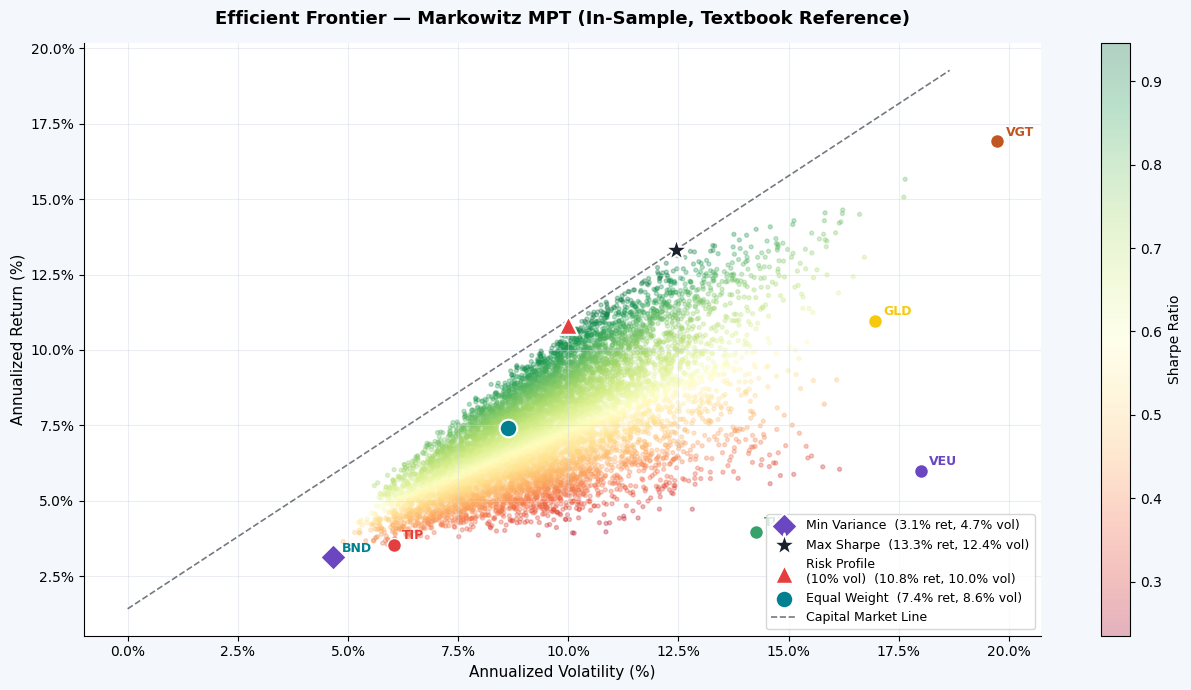

In [ ]:
# Efficient Frontier ────────────────────────────────────────────────
# Simulate 10,000 random portfolios and plot each as a dot.
# The upper-left edge of the cloud is the efficient frontier.
# The three key portfolios are marked on top.
# The Capital Market Line runs from the risk-free rate through Max Sharpe.
#
# This is the in-sample, textbook visualization from section 4.2.3 of the paper.
# It uses full-history inputs — illustrative only, not a prediction.


num_simulations = 10_000
simulated_returns     = np.zeros(num_simulations)
simulated_volatility  = np.zeros(num_simulations)
simulated_sharpe      = np.zeros(num_simulations)

for simulation_index in range(num_simulations):
    random_weights              = np.random.dirichlet(np.ones(num_assets))
    simulated_portfolio_return  = random_weights @ expected_return_vector
    simulated_portfolio_vol     = np.sqrt(random_weights @ covariance_array @ random_weights)
    simulated_returns[simulation_index]    = simulated_portfolio_return * 100
    simulated_volatility[simulation_index] = simulated_portfolio_vol   * 100
    simulated_sharpe[simulation_index]     = (
        (simulated_portfolio_return - avg_annual_risk_free) / simulated_portfolio_vol
    )

fig, ax = plt.subplots(figsize=(13, 7))

# Random portfolio cloud — color shows Sharpe ratio
scatter = ax.scatter(
    simulated_volatility, simulated_returns,
    c=simulated_sharpe, cmap="RdYlGn",
    alpha=0.3, s=8, zorder=1
)
plt.colorbar(scatter, ax=ax, label="Sharpe Ratio")

# Individual assets as labeled dots
asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]
for asset_index, asset_name in enumerate(assets):
    asset_vol    = np.sqrt(covariance_array[asset_index, asset_index]) * 100
    asset_return = expected_return_vector[asset_index] * 100
    ax.scatter(asset_vol, asset_return, s=100,
               color=asset_colors[asset_index], zorder=5,
               edgecolors="white", linewidths=1)
    ax.annotate(asset_name, (asset_vol, asset_return),
                xytext=(6, 4), textcoords="offset points",
                fontsize=9, color=asset_colors[asset_index], fontweight="bold")

# Key portfolios
key_portfolios = [
    (min_variance_weights,  "Min Variance",   "#6B46C1", "D",  180),
    (max_sharpe_weights,    "Max Sharpe",      "#1A202C", "*",  300),
    (risk_profile_weights,  "Risk Profile\n(10% vol)", "#E53E3E", "^", 180),
    (equal_weights,         "Equal Weight",    "#028090", "o",  160),
]
for portfolio_weights, label, color, marker, size in key_portfolios:
    portfolio_return = portfolio_weights.values @ expected_return_vector * 100
    portfolio_vol    = np.sqrt(portfolio_weights.values @ covariance_array @ portfolio_weights.values) * 100
    ax.scatter(portfolio_vol, portfolio_return,
               s=size, color=color, marker=marker, zorder=6,
               edgecolors="white", linewidths=1.5,
               label=f"{label}  ({portfolio_return:.1f}% ret, {portfolio_vol:.1f}% vol)")

# Capital Market Line — from risk-free rate through Max Sharpe tangency point
# This is the efficient CAL described in section 4.3 of the paper
max_sharpe_vol    = np.sqrt(max_sharpe_weights.values @ covariance_array @ max_sharpe_weights.values) * 100
max_sharpe_return = max_sharpe_weights.values @ expected_return_vector * 100
capital_market_line_x = np.linspace(0, max_sharpe_vol * 1.5, 200)
capital_market_line_y = (
    avg_annual_risk_free * 100
    + (max_sharpe_return - avg_annual_risk_free * 100) / max_sharpe_vol
    * capital_market_line_x
)
ax.plot(capital_market_line_x, capital_market_line_y,
        color="#1A202C", linewidth=1.2, linestyle="--",
        alpha=0.6, label="Capital Market Line")

ax.set_xlabel("Annualized Volatility (%)", fontsize=11)
ax.set_ylabel("Annualized Return (%)", fontsize=11)
ax.set_title("Efficient Frontier — Markowitz MPT (In-Sample, Textbook Reference)",
             fontsize=13, fontweight="bold", pad=14)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
# Rolling Risk Profile — The Realistic Simulation ──────────────────
# This is how a real robo-advisor using MPT actually operates:

#   Every month:
#   1. Look back 36 months — compute expected returns and covariance
#   2. Maximize expected return subject to investor's vol target (10%)
#   3. Apply rebalancing threshold — only trade if drift exceeds 5%
#   4. Earn next month's return, record everything, move forward

# The gap between this and the static Max Sharpe performance is your key finding:
# how much of MPT's apparent edge disappears when you remove look-ahead bias.

rolling_weight_history  = []
rolling_return_history  = []
rolling_date_history    = []
monthly_turnover        = []

current_weights = np.ones(num_assets) / num_assets  # start at equal weight

for month_index in range(LOOKBACK, len(returns)):
    # Use only the past 36 months — no future data
    return_window = returns.iloc[month_index - LOOKBACK : month_index]

    # Estimate expected return and covariance from this window only
    window_expected_return   = return_window.mean().values * 12
    window_covariance_matrix = return_window.cov().values  * 12

    # Maximize expected return subject to investor vol target
    # This is exactly the optimization problem in Losada Noya section 4.1
    def negative_window_return(weights, expected_return=window_expected_return):
        return -(weights @ expected_return)

    def portfolio_vol_constraint(weights, covariance=window_covariance_matrix):
        portfolio_volatility = np.sqrt(weights @ covariance @ weights)
        return portfolio_volatility - VOL_TARGET

    rolling_constraints = [
        {"type": "eq",  "fun": lambda weights: np.sum(weights) - 1},
        {"type": "eq",  "fun": portfolio_vol_constraint},
    ]

    try:
        optimization_result = sco.minimize(
            negative_window_return,
            equal_initial_weights,
            method      = "SLSQP",
            bounds      = weight_bounds,
            constraints = rolling_constraints,
            options     = {"ftol": 1e-10, "maxiter": 1000}
        )
        new_target_weights = optimization_result.x
        # If optimizer failed, fall back to equal weight
        if not optimization_result.success:
            new_target_weights = np.ones(num_assets) / num_assets
    except Exception:
        new_target_weights = np.ones(num_assets) / num_assets

    # Rebalancing threshold — only trade if drift exceeds 5%
    weight_drift = np.abs(current_weights - new_target_weights)
    if weight_drift.max() > REBAL_THRESHOLD:
        trade_volume    = weight_drift.sum()
        current_weights = new_target_weights
    else:
        trade_volume = 0.0

    monthly_turnover.append(trade_volume)

    # Earn next month's return
    next_month_return = current_weights @ returns.iloc[month_index].values
    rolling_return_history.append(next_month_return)
    rolling_date_history.append(returns.index[month_index])
    rolling_weight_history.append(current_weights.copy())

    # Let weights drift naturally from this month's returns
    ending_values   = current_weights * (1 + returns.iloc[month_index].values)
    current_weights = ending_values / ending_values.sum()


rolling_weights_df = pd.DataFrame(rolling_weight_history,
                                   index=rolling_date_history, columns=assets)
rolling_returns    = pd.Series(rolling_return_history, index=rolling_date_history)
turnover_series    = pd.Series(monthly_turnover,       index=rolling_date_history)

comparison_period  = rolling_returns.index

# ── Re-align RF scalars to comparison_period ──────────────────────────────────
# Single source of truth for Sharpe calculations — matches the fix in 03_risk_parity.
# comparison_period (188 months) != returns.index (224 months), so RF mean differs.
avg_annual_risk_free  = annual_rf_series.reindex(comparison_period, method="ffill").mean()
avg_monthly_risk_free = monthly_rf_series.reindex(comparison_period, method="ffill").mean()

print(f"Rolling simulation done  : {len(rolling_returns)} months")
print(f"Months rebalanced        : {(turnover_series > 0).sum()} / {len(turnover_series)}")
print(f"Average monthly turnover : {turnover_series.mean()*100:.2f}%")
print(f"RF rate (comparison period): {avg_annual_risk_free*100:.3f}% annual  ← used for Sharpe")

Rolling simulation done  : 188 months
Months rebalanced        : 96 / 188
Average monthly turnover : 20.77%
RF rate (comparison period): 1.414% annual  ← used for Sharpe


In [9]:
# Align Static Returns to Comparison Period 

# Trim all static strategies to the same date range as the rolling simulation.
# Fair comparison — every strategy evaluated on identical time window.

equal_weight_returns   = (returns * equal_weights).sum(axis=1).loc[comparison_period]
min_variance_returns   = (returns * min_variance_weights).sum(axis=1).loc[comparison_period]
max_sharpe_returns     = (returns * max_sharpe_weights).sum(axis=1).loc[comparison_period]

all_strategies = {
    "Equal Weight"          : equal_weight_returns,
    "Min Variance"          : min_variance_returns,
    "Max Sharpe (static)"   : max_sharpe_returns,
    "Risk Profile (rolling)": rolling_returns,
}

print(f"Comparison period : {comparison_period[0].date()} -> {comparison_period[-1].date()}")
print(f"Months            : {len(comparison_period)}")

Comparison period : 2010-05-01 -> 2025-12-01
Months            : 188


In [11]:
# Performance Summary 

def compute_performance_stats(monthly_returns, strategy_label):
    annualized_return     = ((1 + monthly_returns).cumprod().iloc[-1] ** (12 / len(monthly_returns)) - 1) * 100  # geometric CAGR
    annualized_volatility = monthly_returns.std()  * np.sqrt(12) * 100
    sharpe_ratio          = (
        (monthly_returns.mean() - avg_monthly_risk_free) * 12
        / (monthly_returns.std() * np.sqrt(12))
    )
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    dd_series        = (cumulative_value - rolling_peak) / rolling_peak  # renamed to avoid shadowing
    max_drawdown     = dd_series.min() * 100
    final_value      = INITIAL_INVESTMENT * cumulative_value.iloc[-1]   # matches 02_simulate reporting

    return pd.Series({
        "Ann. Return %"  : round(annualized_return,     2),
        "Ann. Vol %"     : round(annualized_volatility, 2),
        "Sharpe Ratio"   : round(sharpe_ratio,          3),
        "Max Drawdown %" : round(max_drawdown,          2),
        "Final Value ($)" : round(final_value,          2),
    }, name=strategy_label)


summary_table = pd.DataFrame([
    compute_performance_stats(monthly_returns, label)
    for label, monthly_returns in all_strategies.items()
])

print("── Performance Summary ──")
print(summary_table.to_string())
print()
print("Key comparison: Max Sharpe (static) vs Risk Profile (rolling)")
print("The gap between these two is the look-ahead bias penalty.")

── Performance Summary ──
                        Ann. Return %  Ann. Vol %  Sharpe Ratio  Max Drawdown %  Final Value ($)
Equal Weight                     7.46        8.09         0.750          -21.17             3.05
Min Variance                     2.58        4.61         0.258          -17.22             1.47
Max Sharpe (static)             13.71       11.93         1.033          -23.49             7.59
Risk Profile (rolling)          10.52       10.44         0.875          -22.94             4.75

Key comparison: Max Sharpe (static) vs Risk Profile (rolling)
The gap between these two is the look-ahead bias penalty.


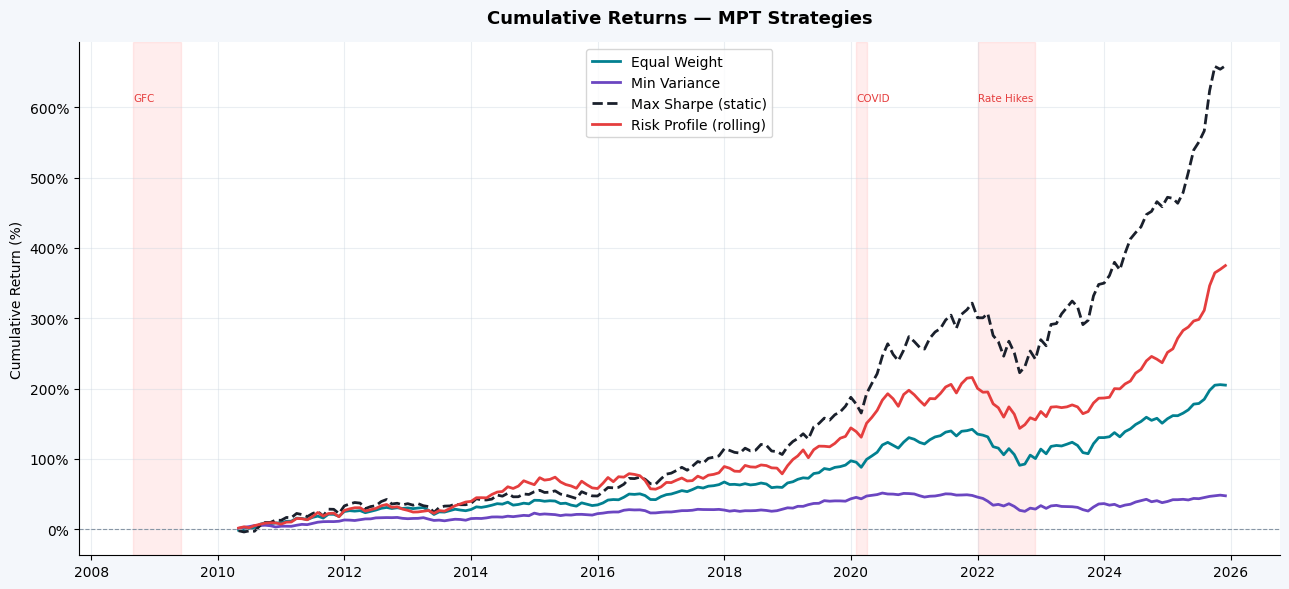

In [12]:
# Cumulative Returns 

fig, ax = plt.subplots(figsize=(13, 6))

for label, monthly_returns in all_strategies.items():
    cumulative_growth_pct = ((1 + monthly_returns).cumprod() - 1) * 100
    ax.plot(cumulative_growth_pct, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if "static" in label else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Returns — MPT Strategies",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

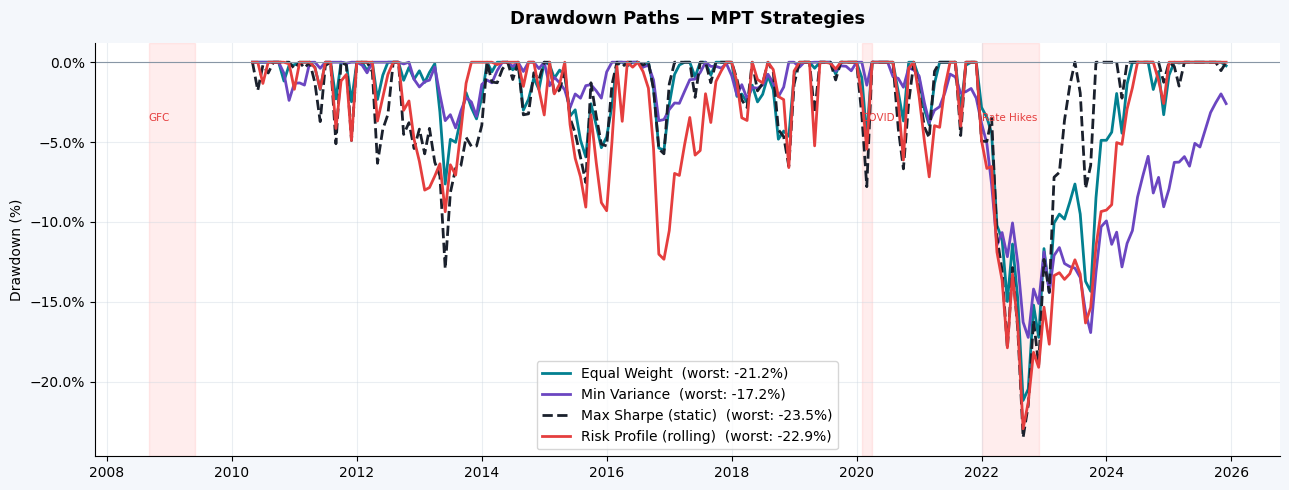

In [13]:
# Drawdown Paths 

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_pct     = ((cumulative_value - rolling_peak) / rolling_peak) * 100
    ax.plot(drawdown_pct,
            label=f"{label}  (worst: {drawdown_pct.min():.1f}%)",
            color=PALETTE[label], linewidth=2,
            linestyle="--" if "static" in label else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_min = ax.get_ylim()[0]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_min * 0.15,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8)
ax.set_title("Drawdown Paths — MPT Strategies",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

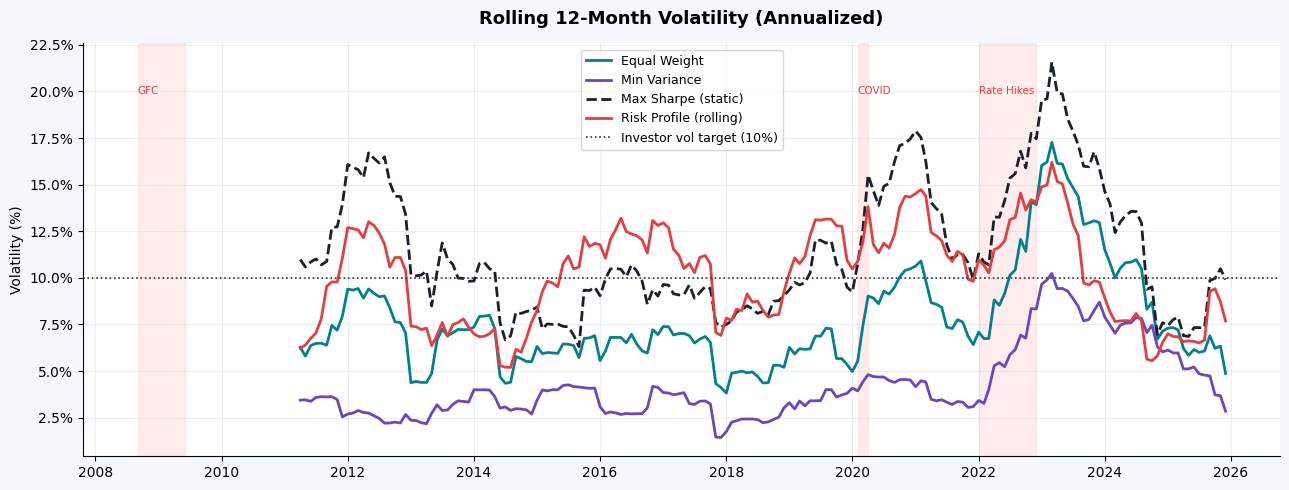

In [14]:
# Rolling 12-Month Volatility 

# Risk Profile (rolling) should stay close to the 10% target line.
# Max Sharpe (static) has no vol constraint — it can go anywhere.

rolling_window_months = 12

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    rolling_vol = (
        monthly_returns.rolling(rolling_window_months).std() * np.sqrt(12) * 100
    )
    ax.plot(rolling_vol, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if "static" in label else "-")

ax.axhline(VOL_TARGET * 100, color="#333", linewidth=1.2,
           linestyle=":", label=f"Investor vol target ({VOL_TARGET*100:.0f}%)")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.set_title(f"Rolling {rolling_window_months}-Month Volatility (Annualized)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Volatility (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# Recovery Dynamics
# How many months did each strategy take to recover from each crisis?

def months_to_recover(monthly_returns, crisis_start, crisis_end):
    cumulative_value  = (1 + monthly_returns).cumprod()
    pre_crisis_values = cumulative_value.loc[:crisis_start]
    if pre_crisis_values.empty:
        return None
    pre_crisis_peak   = pre_crisis_values.max()
    crisis_values     = cumulative_value.loc[crisis_start:crisis_end]
    if crisis_values.empty:
        return None
    trough_date       = crisis_values.idxmin()
    post_trough       = cumulative_value.loc[trough_date:]
    recovered_months  = post_trough[post_trough >= pre_crisis_peak]
    if recovered_months.empty:
        return None
    recovery_date     = recovered_months.index[0]
    months_elapsed    = len(cumulative_value.loc[trough_date:recovery_date]) - 1
    return months_elapsed


print("── Recovery Time (months from trough back to pre-crisis peak) ──\n")
header = f"{'Crisis':<16}" + "".join(f"{label:>24}" for label in all_strategies)
print(header)
print("-" * len(header))

for crisis_start, crisis_end, crisis_label in CRISES:
    row = f"{crisis_label:<16}"
    for label, monthly_returns in all_strategies.items():
        months = months_to_recover(monthly_returns, crisis_start, crisis_end)
        row += f"{'Not recovered':>24}" if months is None else f"{months} months".rjust(24)
    print(row)

── Recovery Time (months from trough back to pre-crisis peak) ──

Crisis                      Equal Weight            Min Variance     Max Sharpe (static)  Risk Profile (rolling)
----------------------------------------------------------------------------------------------------------------
GFC                        Not recovered           Not recovered           Not recovered           Not recovered
COVID                           1 months                1 months                1 months                1 months
Rate Hikes                     21 months           Not recovered               10 months               22 months


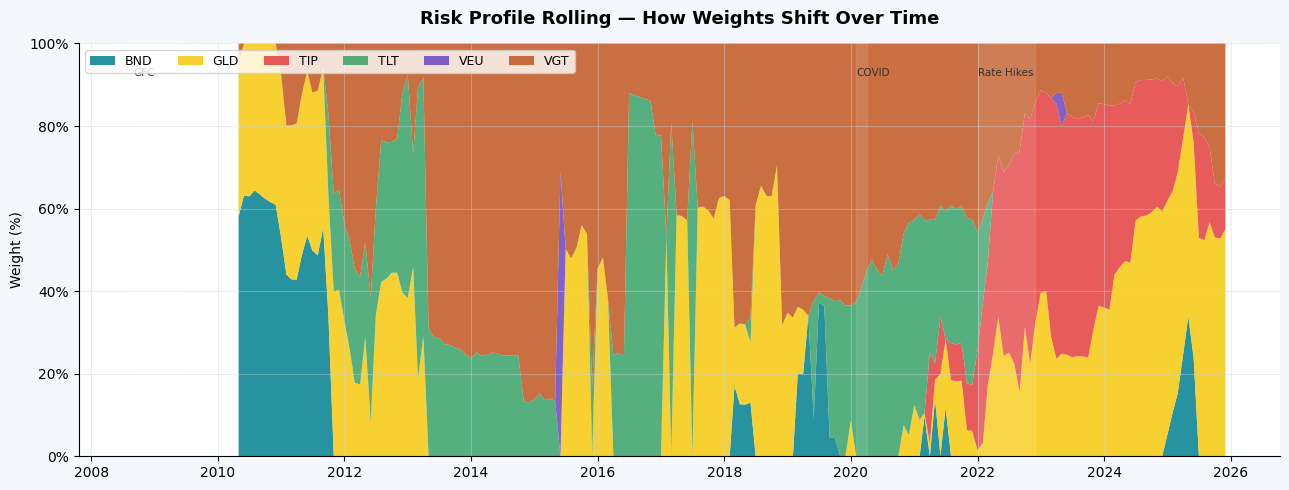

In [ ]:
# Rolling Weight Evolution 

# Shows how the Risk Profile portfolio's weights shift over time.
# During crises, MPT often flees to bonds (BND, TIP, TLT).
# In bull markets it concentrates in VGT.
# This instability is the corner solution problem in action.

asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    rolling_weights_df.index,
    [rolling_weights_df[asset] * 100 for asset in assets],
    labels=assets, colors=asset_colors, alpha=0.85
)

for crisis_start, crisis_end, _ in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.10, color="white", zorder=2)
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), 92,
            crisis_label, fontsize=7.5, color="#333")

ax.set_title("Risk Profile Rolling — How Weights Shift Over Time",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Weight (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, ncol=num_assets, loc="upper left")
plt.tight_layout()
plt.show()